## **PERTEMUAN 10: ALGORITMA KLASIFIKASI (BAGIAN 2): METODE ENSEMBLE (RANDOM FOREST) DAN PENANGANAN IMBALANCED DATASET**
---
## **Aktivitas Hands-on: Customer Churn**
---
### NAMA  : SHERLY EKA WINDIANI
### NIM   : 240401010222
### KELAS : IF403


In [63]:
import pandas as pd

df = pd.read_csv("sample_data/telco_churn.csv")
print("Dimensi Dataset:", df.shape)
print("\nProporsi Kelas Churn:")
print(df["Churn"].value_counts(normalize=True))

Dimensi Dataset: (7043, 21)

Proporsi Kelas Churn:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split

if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

if 'Churn' in df.columns:
    X = df.drop(columns=['Churn'])
    y = df['Churn'].apply(lambda val: 1 if str(val).strip().lower() in ['yes', 'true', '1'] else 0)
else:
    print("Kolom 'Churn' tidak ditemukan!")

X = pd.get_dummies(X, drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Berhasil! Ukuran data latih (X_tr):", X_tr.shape)
print("Berhasil! Ukuran data uji (X_te):", X_te.shape)

Berhasil! Ukuran data latih (X_tr): (5634, 30)
Berhasil! Ukuran data uji (X_te): (1409, 30)


/tmp/ipykernel_2458/634993500.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_tr, y_tr)
print("Model Random Forest berhasil dilatih!")

Model Random Forest berhasil dilatih!


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8246208891988943


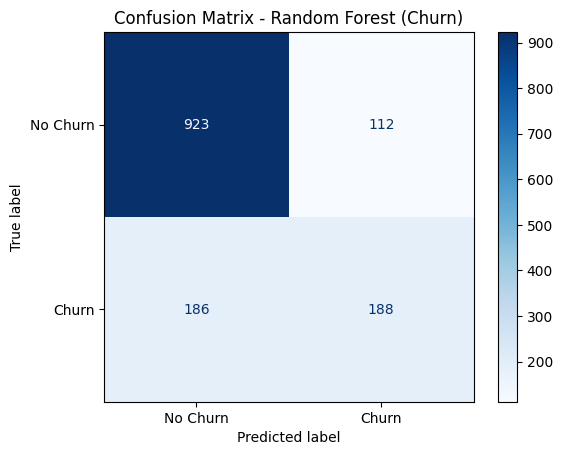

In [66]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

proba = rf.predict_proba(X_te)[:, 1]
pred = (proba >= 0.5).astype(int)

print("--- Classification Report ---")
print(classification_report(y_te, pred))
print("ROC-AUC Score:", roc_auc_score(y_te, proba))

cm = confusion_matrix(y_te, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest (Churn)")
plt.show()

## Kesimpulan dan Interpretasi
- **Penanganan Ketimpangan Data:** Model Random Forest dengan parameter `class_weight="balanced"` terbukti efektif menangani dataset *customer churn* yang bersifat *imbalanced*.
- **Analisis Metrik (Accuracy Paradox):** Pada data *churn* yang tidak seimbang, akurasi tinggi dapat sangat menyesatkan karena model yang asal menebak mayoritas tetap bisa mendapat akurasi besar tanpa mendeteksi pelanggan yang benar-benar berhenti. Oleh karena itu, metrik **Recall** menjadi yang paling krusial agar perusahaan tidak melewatkan pelanggan berisiko tinggi, didukung oleh **Precision**, **F1-Score**, serta **ROC-AUC** untuk evaluasi performa secara menyeluruh
- **Temuan Utama:** Confusion Matrix memperlihatkan peningkatan kemampuan model dalam mengenali kelas minoritas (churn) secara lebih adil setelah penerapan ensemble dan class weighting.